In [16]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
df = pd.read_csv('mercedes_benz_listings_cleaned.csv')
features = ['Mileage_Miles']
n_features = len(features)
#prepare data
data = df.dropna()



idx_train = data.sample(frac = 0.8).index

X_train = data.loc[idx_train,features].values
Y_train = data.loc[idx_train,'Price_USD'].values

X_test = data.drop(idx_train).loc[:,features].values
Y_test = data.drop(idx_train)['Price_USD'].values

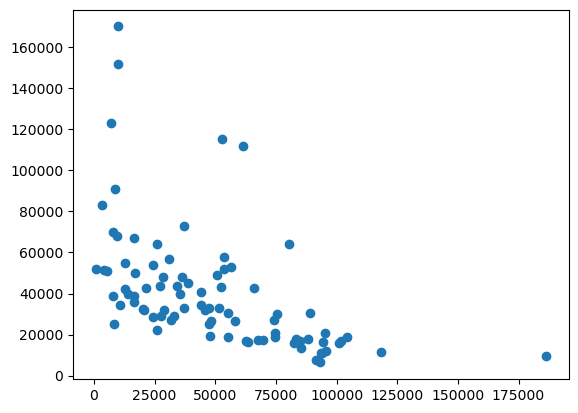

In [17]:
plt.scatter(X_train,Y_train)

# FEATURES SCALING

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled

array([[-0.34511069],
       [ 2.0388516 ],
       [-0.67224734],
       [-1.42076187],
       [-0.0375169 ],
       [-0.47281613],
       [ 0.26919394],
       [ 1.17902525],
       [-1.21409039],
       [-0.72581357],
       [-0.04802412],
       [-0.5959596 ],
       [-0.62436148],
       [-0.9585618 ],
       [-0.94831946],
       [ 0.18501843],
       [ 0.50688674],
       [-0.04022464],
       [ 1.30823172],
       [ 4.0498222 ],
       [-1.23507541],
       [ 0.40478715],
       [-0.02406648],
       [ 0.5444714 ],
       [-0.80271938],
       [ 1.0620625 ],
       [-0.6437866 ],
       [ 1.15568568],
       [ 1.32915786],
       [-1.21144151],
       [-0.67330689],
       [ 0.37255911],
       [ 0.07829801],
       [-0.94051999],
       [-0.29769575],
       [ 0.75549882],
       [-1.02610823],
       [-1.06101458],
       [ 0.22881324],
       [-1.31954524],
       [ 1.36321068],
       [-0.14500255],
       [ 1.55354741],
       [-0.82814862],
       [-1.34641665],
       [ 0

In [19]:
Y_train = Y_train.reshape([X_train.shape[0],1])

X_trainb = np.hstack([X_train_scaled,np.ones((X_train.shape[0],1))])

# LINEAR REGRESSION CLASS

In [ ]:
class LR :
    def __init__(self,n_features,ridge_lamda = 0):
        self.w = np.random.randn(len(features) + 1,1)
        self.costs = []
        self.lamda = ridge_lamda

    def predict(self,X):
        return X@self.w

    def cost(self, X,y):
        m = len(y)
        ridge = self.lamda * np.sum(self.w **2)
        return (1/(2*m)) * (np.sum((X@self.w - y) **2) + ridge)

    def grad(self,X,y):
        m = len(y)
        ridge = self.lamda * self.w
        return (1/m) * ( X.T.dot(X@self.w - y) + ridge)

    def descente_gradient(self,X,y,alpha,n_iterations):
        for i in range(0,n_iterations):
            self.w = self.w -alpha * self.grad(X,y)
            self.costs.append(self.cost(X,y))

    def fit_analytique(self,X,y):
        self.w = 0
        self.w = np.linalg.inv(X.T@X).dot(X.T@y)
        

In [ ]:
lr = LR(n_features)
lr.descente_gradient(X_trainb,Y_train,alpha=0.1,n_iterations=1000)

lr2 = LR(n_features)
lr2.fit_analytique(X_trainb,Y_train)

predictions =lr.predict(X_trainb)
predictions2  = lr2.predict(X_trainb)

0


array([[-15730.33211273],
       [ 40762.3255814 ]])

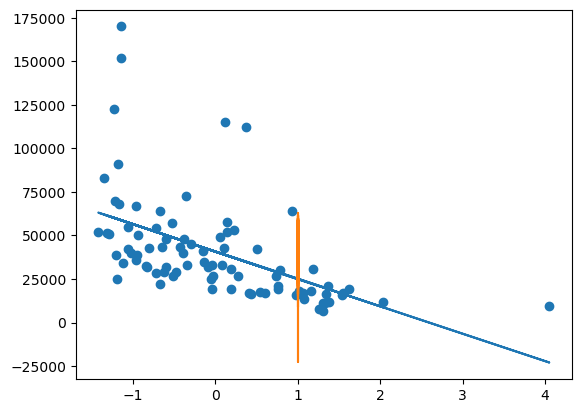

In [27]:
plt.scatter(X_train_scaled,Y_train)
plt.plot(X_trainb,predictions2)
print(np.isnan(Y_train).sum())
lr.w

In [28]:
from sklearn.metrics import r2_score
df = pd.DataFrame({
    'prediction' : [r2_score(Y_train,predictions)],
    'prediction2' : [r2_score(Y_train,predictions2)]
    })
print(np.allclose(predictions,predictions2))
df

True


,prediction,prediction2
0,0.278984,0.278984


# sklearn model

In [33]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

model = make_pipeline(StandardScaler(), LinearRegression())
model.fit(X_train, Y_train)

pred = model.predict(X_train)
print(r2_score(Y_train,pred))

0.278984013342472
